# Phase 1 — WSD × SAM 메인 그리드

프로젝트의 핵심 실험. `sam_off` / ρ=0.02 / 0.05 / 0.1 을 **같은 Stage 1 체크포인트에서
분기**시켜 시드별로 반복한다.

| | |
|---|---|
| 소요 | 시드당 약 65분 (Stage 1 15분 + arm 4개) |
| 5시드 | 약 5.5시간 |
| 판정 | Gate A 는 첫 arm(≈23분)에 가능, Gate B/C 는 완주 후 |

**중단돼도 괜찮다.** arm 이 끝날 때마다 JSON 이 저장되고, 다시 실행하면 건너뛴다.

이 노트북은 **자체완결형**이다. 외부 `.py` 없이 혼자 돈다.
노트북판의 결함 세 가지(Stage 2 시드 미고정 · probe 의 전역 RNG 의존 ·
sharpness 측정식의 1차항)는 아래 정의 셀에서 모두 교정됐다.
자세한 내용은 `docs/PROGRESS.md` §4.2, §6.

> ⚠️ 세션을 끄기 전에 **마지막 셀에서 결과를 반드시 회수**할 것.

In [ ]:
# ══ 1. 셋업 ═══════════════════════════════════════════════════════════════
import os, sys, math, json, time, glob, random, tarfile, urllib.request
from datetime import datetime
from collections import defaultdict

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms

# ── 결과 저장 위치 ────────────────────────────────────────────────────────
# /content 는 세션이 끊기면 사라진다. 어느 쪽으로 돌리느냐에 따라 다르다.
#
#   CLI (colab exec)  : 기본값 그대로. 세션을 살려두고 끝나면 colab download 로 회수.
#                       drive.mount 는 대화형이라 헤드리스에서 멈출 수 있으므로 쓰지 않는다.
#   Colab 웹에서 5시간 : USE_DRIVE = True 로 두면 중단돼도 이어서 갈 수 있다.
USE_DRIVE = False

OUT_DIR = '/content/out'
if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        OUT_DIR = '/content/drive/MyDrive/wsd_sam/out'
    except Exception as e:
        print('Drive 마운트 실패 → /content/out 사용:', e)

DATA_DIR = os.environ.get('DATA_DIR', '/content/data')
OUT_DIR  = os.environ.get('OUT_DIR', OUT_DIR)
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device :', device,
      f'({torch.cuda.get_device_name(0)})' if device.type == 'cuda' else '')
print('torch  :', torch.__version__)
print('출력   :', OUT_DIR)
if device.type != 'cuda':
    print('\n⚠️ GPU 가 아니다. 런타임 → 런타임 유형 변경 → T4 GPU 로 바꿀 것.')

device : cuda (Tesla T4)
torch  : 2.11.0+cu128
출력   : /content/out


In [ ]:
# ══ 2. 재현성 ═════════════════════════════════════════════════════════════
# 노트북판의 가장 큰 결함이 "Stage 2 에 시드가 없다"는 것이었다.
# sam_off 셀이 RNG 를 소모한 뒤 sam_on 셀이 시작돼, 두 arm 이 서로 다른
# 데이터 순서를 봤다. 아래 세 함수로 그 경로를 원천 차단한다.
def seed_everything(seed):
    random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def loader_generator(seed):
    g = torch.Generator(); g.manual_seed(seed); return g

def worker_init(worker_id):
    random.seed(torch.initial_seed() % 2**32 + worker_id)

print('시드 유틸 준비 완료')

시드 유틸 준비 완료


In [ ]:
# ══ 3. 데이터 ═════════════════════════════════════════════════════════════
CIFAR_URL = 'https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz'
C10_MEAN, C10_STD = (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)

def prepare_data(data_dir=DATA_DIR):
    root = os.path.join(data_dir, 'cifar10')
    if not os.path.exists(root):
        tgz = os.path.join(data_dir, 'cifar10.tgz')
        if not os.path.exists(tgz):
            print('CIFAR-10 다운로드 중...', flush=True)
            urllib.request.urlretrieve(CIFAR_URL, tgz)
        print('압축 해제 중...', flush=True)
        with tarfile.open(tgz, 'r:gz') as tar:
            tar.extractall(path=data_dir, filter='data')
    return root

def build_loaders(seed, batch_size=128, num_workers=2):
    root = prepare_data()
    tf_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(),
        transforms.ToTensor(), transforms.Normalize(C10_MEAN, C10_STD)])
    tf_eval = transforms.Compose([
        transforms.ToTensor(), transforms.Normalize(C10_MEAN, C10_STD)])
    train = datasets.ImageFolder(os.path.join(root, 'train'), transform=tf_train)
    test  = datasets.ImageFolder(os.path.join(root, 'test'),  transform=tf_eval)
    # probe 전용: 같은 train 이미지지만 augmentation 없이 결정론적으로 읽는다
    probe_src = datasets.ImageFolder(os.path.join(root, 'train'), transform=tf_eval)
    tl = DataLoader(train, batch_size=batch_size, shuffle=True, num_workers=num_workers,
                    pin_memory=True, generator=loader_generator(seed),
                    worker_init_fn=worker_init)
    vl = DataLoader(test, batch_size=batch_size, shuffle=False,
                    num_workers=num_workers, pin_memory=True)
    return tl, vl, probe_src

def make_probe(probe_src, n=384, batch_size=128, probe_seed=1234):
    """sharpness 측정용 고정 배치.
    인덱스는 별도 Generator 로 뽑고 이미지는 augmentation 이 없으므로,
    세션이 달라도 항상 같은 텐서가 나온다."""
    g = torch.Generator().manual_seed(probe_seed)
    idx = torch.randperm(len(probe_src), generator=g)[:n].tolist()
    loader = DataLoader(Subset(probe_src, idx), batch_size=batch_size, shuffle=False)
    return [(x.to(device), y.to(device)) for x, y in loader]

print('데이터 함수 준비 완료')

데이터 함수 준비 완료


In [ ]:
# ══ 4. 옵티마이저 + SAM ═══════════════════════════════════════════════════
class Lion(optim.Optimizer):
    """update = sign(b1*m + (1-b1)*g),  m = b2*m + (1-b2)*g"""
    def __init__(self, params, lr=2e-4, betas=(0.9, 0.99), weight_decay=0.5):
        super().__init__(params, dict(lr=lr, betas=betas, weight_decay=weight_decay))

    @torch.no_grad()
    def step(self, closure=None):
        for group in self.param_groups:
            lr, wd = group['lr'], group['weight_decay']
            b1, b2 = group['betas']
            for p in group['params']:
                if p.grad is None: continue
                st = self.state[p]
                if 'exp_avg' not in st: st['exp_avg'] = torch.zeros_like(p)
                m, g = st['exp_avg'], p.grad
                if wd: p.mul_(1 - lr * wd)
                p.add_(m.mul(b1).add_(g, alpha=1-b1).sign_(), alpha=-lr)
                m.mul_(b2).add_(g, alpha=1-b2)


class SAMAscent:
    """SAM 을 '옵티마이저'가 아니라 '그래디언트 변환기'로 분리한 것.
    perturbation 만 담당하고 step 은 외부 옵티마이저가 하므로,
    옵티마이저를 교체하지 않고 SAM 을 켜고 끌 수 있다 → 모멘텀이 연속된다."""
    def __init__(self, params, rho=0.0):
        self.params = [p for p in params if p.requires_grad]
        self.rho = rho; self._e_w = {}

    def set_rho(self, rho): self.rho = rho

    @torch.no_grad()
    def grad_norm(self):
        gs = [p.grad.norm(p=2) for p in self.params if p.grad is not None]
        return torch.norm(torch.stack(gs), p=2) if gs else torch.tensor(0.0)

    @torch.no_grad()
    def ascent(self):
        if self.rho <= 0: return False
        gn = self.grad_norm()
        if gn.item() < 1e-12: return False
        scale = self.rho / (gn + 1e-12)
        self._e_w.clear()
        for p in self.params:
            if p.grad is None: continue
            e = p.grad * scale.to(p.device); p.add_(e); self._e_w[p] = e
        return True

    @torch.no_grad()
    def restore(self):
        for p, e in self._e_w.items(): p.sub_(e)
        self._e_w.clear()

def build_model():
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, 10)
    return m.to(device)

print('Lion / SAMAscent / ResNet-18 준비 완료')

Lion / SAMAscent / ResNet-18 준비 완료


In [ ]:
# ══ 5. WSD 스케줄 + sharpness 측정 ════════════════════════════════════════
def wsd_lr(epoch, total_epochs, peak_lr, warmup_epochs, decay_epochs):
    """warmup(선형 상승) → stable(유지) → decay(선형 하강)"""
    stable_end = total_epochs - decay_epochs
    if epoch < warmup_epochs:
        return peak_lr * (epoch + 1) / warmup_epochs
    if epoch < stable_end:
        return peak_lr
    prog = min(1.0, max(0.0, (epoch - stable_end + 1) / decay_epochs))
    return peak_lr * (1.0 - prog)


@torch.no_grad()
def _perturb(e_ws, sign):
    for p, e in e_ws: p.add_(e, alpha=sign)


def measure_sharpness(model, criterion, probe, rho=0.05):
    """세 값을 함께 반환한다.

    one_sided : L(w+e) − L(w)
        테일러 전개하면 ≈ rho*||g|| + (1/2)rho^2 * (g'Hg)/||g||^2 이다.
        즉 1차항이 그래디언트 노름이라, 이 값은 곡률이 아니라 ||g|| 를
        상당 부분 재고 있다. 과거 결과와 비교하려고 유지한다.

    symmetric : (1/2)(L(w+e) + L(w−e)) − L(w)
        1차항이 상쇄되어 곡률 항만 남는다. 이쪽이 우리가 재려던 것.

    grad_norm : 위 해석을 사후 검증하기 위한 원자료 (Gate A).
    """
    was_training = model.training
    model.eval()
    one, sym, gns = [], [], []
    for x, y in probe:
        with torch.no_grad():
            l0 = criterion(model(x), y).item()
        model.zero_grad(set_to_none=True)
        criterion(model(x), y).backward()
        gs = [p.grad.norm(p=2) for p in model.parameters() if p.grad is not None]
        gn = torch.norm(torch.stack(gs), p=2); gns.append(gn.item())
        scale = rho / (gn + 1e-12)
        e_ws = [(p, p.grad * scale) for p in model.parameters() if p.grad is not None]
        with torch.no_grad():
            _perturb(e_ws, +1.0);  lp = criterion(model(x), y).item()
            _perturb(e_ws, -2.0);  lm = criterion(model(x), y).item()
            _perturb(e_ws, +1.0)                     # 원위치 복원
        model.zero_grad(set_to_none=True)
        one.append(lp - l0); sym.append(0.5 * (lp + lm) - l0)
    if was_training: model.train()
    n = len(one)
    return sum(one)/n, sum(sym)/n, sum(gns)/n


@torch.no_grad()
def evaluate(model, loader):
    model.eval(); correct = total = 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        total += y.size(0); correct += model(x).max(1)[1].eq(y).sum().item()
    return 100.0 * correct / total

print('스케줄 / sharpness / 평가 함수 준비 완료')

스케줄 / sharpness / 평가 함수 준비 완료


In [ ]:
# ══ 6. 실시간 그래프 ══════════════════════════════════════════════════════
import matplotlib.pyplot as plt
from IPython.display import clear_output

# 기본값은 꺼둔다. 켜면 clear_output 으로 화면을 새로 그리기 때문에
# 에폭 로그가 쌓이지 않고 매번 최신 한 줄만 남는다.
# 로그를 한 줄씩 쌓아 보려면 그대로 두고, 그래프가 필요하면 'on': True 로.
LIVE = {'on': False, 'every': 1}

def live_plot(tag, history, sharp):
    if not LIVE['on'] or len(history['epoch']) % LIVE['every']: return
    clear_output(wait=True)
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].plot(history['epoch'], history['train_acc'], lw=1.2, label='train')
    ax[0].plot(history['epoch'], history['test_acc'],  lw=1.6, label='test')
    ax[0].set_xlabel('epoch'); ax[0].set_ylabel('accuracy (%)')
    ax[0].set_title(f'{tag} — test {history["test_acc"][-1]:.2f}%')
    ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
    if sharp['epoch']:
        ax[1].plot(sharp['epoch'], sharp['one_sided'], 'o-', ms=3,
                   color='tab:orange', label='one-sided')
        ax[1].plot(sharp['epoch'], sharp['symmetric'], 's-', ms=3,
                   color='tab:purple', label='symmetric (curvature)')
        ax[1].set_xlabel('epoch'); ax[1].set_ylabel('sharpness')
        ax[1].set_title('sharpness (lower = flatter)')
        ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
    ax[2].plot(history['epoch'], history['grad_norm'], color='tab:brown', lw=1.2)
    ax[2].set_xlabel('epoch'); ax[2].set_ylabel('grad norm', color='tab:brown')
    ax[2].grid(alpha=.3); ax[2].set_title('grad norm & rho')
    a2 = ax[2].twinx(); a2.plot(history['epoch'], history['rho'],
                                color='tab:green', lw=1.4)
    a2.set_ylabel('rho', color='tab:green')
    plt.tight_layout(); plt.show()
    print(f'[{tag}] epoch {history["epoch"][-1]} | '
          f'loss {history["train_loss"][-1]:.4f} | '
          f'test {history["test_acc"][-1]:.2f}% | '
          f'{sum(history["time"])/60:.1f}분 경과', flush=True)

print('그래프 훅 준비 완료 — 기본 꺼짐. 켜려면 LIVE["on"] = True')

그래프 훅 준비 완료 — 기본 꺼짐. 켜려면 LIVE["on"] = True


In [ ]:
# ══ 7. 학습 루프 ══════════════════════════════════════════════════════════
# Stage 1 과 Stage 2 가 이 함수 하나를 공유한다.
# 노트북판처럼 셀을 복사해 플래그만 바꾸는 구조가 아니므로,
# 두 arm 의 코드 경로가 완전히 동일함이 구조적으로 보장된다.
def new_history():
    keys = ['epoch','phase','lr','rho','train_loss','train_acc','test_acc',
            'grad_norm','ascent_gap','time']
    return ({k: [] for k in keys},
            {'epoch': [], 'one_sided': [], 'symmetric': [], 'probe_grad_norm': []})


def run_epochs(model, optimizer, sam, criterion, train_loader, test_loader,
               probe, epoch_range, cfg, history, sharp, rho_fn, tag):
    stable_end = cfg['total_epochs'] - cfg['decay_epochs']
    last = epoch_range[-1]
    for epoch in epoch_range:
        lr_now = wsd_lr(epoch, cfg['total_epochs'], cfg['peak_lr'],
                        cfg['warmup_epochs'], cfg['decay_epochs'])
        for g in optimizer.param_groups: g['lr'] = lr_now
        rho_now = rho_fn(epoch) if rho_fn else 0.0
        sam.set_rho(rho_now)

        model.train()
        run_loss = run_gap = run_gn = 0.0; correct = total = nb = 0
        t0 = time.time()
        for x, y in train_loader:
            x = x.to(device, non_blocking=True); y = y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            out = model(x); loss = criterion(out, y); loss.backward()
            total += y.size(0); correct += out.max(1)[1].eq(y).sum().item()
            run_gn += sam.grad_norm().item()

            gap = 0.0
            if sam.ascent():                       # w -> w+e
                optimizer.zero_grad(set_to_none=True)
                loss_adv = criterion(model(x), y); loss_adv.backward()
                gap = loss_adv.item() - loss.item()
                sam.restore()                      # w+e -> w
            if cfg['grad_clip']:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
            optimizer.step()
            run_loss += loss.item(); run_gap += gap; nb += 1

        dt = time.time() - t0
        tr_loss, tr_acc = run_loss/nb, 100.0*correct/total
        te_acc = evaluate(model, test_loader)
        phase = ('warmup' if epoch < cfg['warmup_epochs']
                 else 'stable' if epoch < stable_end else 'decay')
        for k, v in [('epoch',epoch+1),('phase',phase),('lr',lr_now),('rho',rho_now),
                     ('train_loss',tr_loss),('train_acc',tr_acc),('test_acc',te_acc),
                     ('grad_norm',run_gn/nb),('ascent_gap',run_gap/nb),('time',dt)]:
            history[k].append(v)

        extra = ''
        if (epoch+1) % cfg['sharpness_interval'] == 0 or epoch == last:
            o, s, g = measure_sharpness(model, criterion, probe, cfg['sharpness_rho'])
            sharp['epoch'].append(epoch+1); sharp['one_sided'].append(o)
            sharp['symmetric'].append(s);   sharp['probe_grad_norm'].append(g)
            extra = f' | Sharp1 {o:.4f} | SharpSym {s:.6f} | pg {g:.4f}'
        print(f'[{tag}|{phase:6s}] Ep [{epoch+1}/{cfg["total_epochs"]}] | {dt:.1f}s | '
              f'Loss {tr_loss:.4f} | Train {tr_acc:.2f}% | Test {te_acc:.2f}% | '
              f'lr {lr_now:.5f} | rho {rho_now:.4f} | gn {run_gn/nb:.3f}{extra}', flush=True)
        try:
            live_plot(tag, history, sharp)
        except Exception as e:
            print('  (그래프 오류 무시:', e, ')', flush=True)

print('학습 루프 준비 완료')

학습 루프 준비 완료


In [ ]:
# ══ 8. Stage 1 / Stage 2 ══════════════════════════════════════════════════
def stage1(seed, cfg, force=False):
    """warmup+stable. 시드당 한 번만 학습하고 체크포인트로 캐시한다.
    이 체크포인트를 모든 arm 이 공유하므로 rho 스윕이 거의 공짜로 얹힌다."""
    path = os.path.join(OUT_DIR, f'stage1_seed{seed}.pt')
    if os.path.exists(path) and not force:
        print(f'Stage 1 캐시 재사용: {path}', flush=True); return path

    seed_everything(seed)
    tl, vl, ps = build_loaders(seed, cfg['batch_size'])
    probe = make_probe(ps)
    model = build_model()
    opt = Lion(model.parameters(), lr=cfg['peak_lr'], weight_decay=cfg['weight_decay'])
    sam = SAMAscent(model.parameters()); crit = nn.CrossEntropyLoss()
    hist, sharp = new_history()

    print(f'\n=== Stage 1 (seed {seed}) — {cfg["stable_end"]} epochs ===\n', flush=True)
    run_epochs(model, opt, sam, crit, tl, vl, probe,
               range(cfg['stable_end']), cfg, hist, sharp, None, f'S1-s{seed}')
    torch.save({'model': model.state_dict(), 'optimizer': opt.state_dict(),
                'cfg': cfg, 'seed': seed, 'history': hist,
                'sharpness_history': sharp}, path)
    print(f'\nStage 1 저장: {path}', flush=True)
    return path


def stage2(seed, rho, cfg, ckpt_path):
    """decay 구간. Stage 1 체크포인트에서 분기한다."""
    tag = f'sam{rho:g}' if rho > 0 else 'samoff'
    arm = f'seed{seed}_{tag}_d{cfg["decay_epochs"]}'
    out = os.path.join(OUT_DIR, f'arm_{arm}.json')
    if os.path.exists(out):
        print(f'skip {arm} (이미 있음)', flush=True)
        return json.load(open(out, encoding='utf-8'))

    ck = torch.load(ckpt_path, map_location=device, weights_only=False)
    stable_end = ck['cfg']['stable_end']

    # ★ 여기가 노트북판에 없던 부분.
    #   시드를 다시 고정해 모든 arm 이 동일한 데이터 순서를 보게 한다.
    seed_everything(seed + 10_000)
    tl, vl, ps = build_loaders(seed + 10_000, cfg['batch_size'])
    probe = make_probe(ps)

    model = build_model(); model.load_state_dict(ck['model'])
    opt = Lion(model.parameters(), lr=cfg['peak_lr'], weight_decay=cfg['weight_decay'])
    opt.load_state_dict(ck['optimizer'])          # 모멘텀까지 복원
    sam = SAMAscent(model.parameters()); crit = nn.CrossEntropyLoss()
    hist  = {k: list(v) for k, v in ck['history'].items()}
    sharp = {k: list(v) for k, v in ck['sharpness_history'].items()}

    def rho_fn(ep):
        if rho <= 0: return 0.0
        prog = (ep - stable_end + 1) / max(1, cfg['rho_ramp_epochs'])
        return rho * min(1.0, max(0.0, prog))

    a0, o0, s0 = hist['test_acc'][-1], sharp['one_sided'][-1], sharp['symmetric'][-1]
    print(f'\n=== Stage 2 [{arm}] — 출발점 ep{stable_end}: '
          f'Test {a0:.2f}% | SharpSym {s0:.6f} ===\n', flush=True)
    run_epochs(model, opt, sam, crit, tl, vl, probe,
               range(stable_end, cfg['total_epochs']), cfg, hist, sharp,
               rho_fn, f'S2-{arm}')

    best = max(hist['test_acc'])
    rec = {'arm': arm, 'seed': seed, 'rho_max': rho, 'cfg': cfg,
           'decay_epochs': cfg['decay_epochs'], 'stable_end': stable_end,
           'results': {
               'decay_start_test_acc': a0, 'decay_start_one_sided': o0,
               'decay_start_symmetric': s0,
               'final_train_acc': hist['train_acc'][-1],
               'final_test_acc': hist['test_acc'][-1], 'best_test_acc': best,
               'best_epoch': hist['epoch'][hist['test_acc'].index(best)],
               'final_gap': hist['train_acc'][-1] - hist['test_acc'][-1],
               'final_one_sided': sharp['one_sided'][-1],
               'final_symmetric': sharp['symmetric'][-1],
               'final_probe_grad_norm': sharp['probe_grad_norm'][-1],
               'decay_time_min': sum(hist['time'][stable_end:]) / 60},
           'history': hist, 'sharpness_history': sharp,
           'timestamp': datetime.now().isoformat(timespec='seconds')}
    json.dump(rec, open(out, 'w', encoding='utf-8'), ensure_ascii=False, indent=2)
    r = rec['results']
    print(f'\n=== [{arm}] 완료 ===', flush=True)
    print(f'  Test     {a0:.2f}% -> {r["final_test_acc"]:.2f}% '
          f'({r["final_test_acc"]-a0:+.2f}%p)', flush=True)
    print(f'  SharpSym {s0:.6f} -> {r["final_symmetric"]:.6f}', flush=True)
    print(f'  {r["decay_time_min"]:.1f}분 | 저장: {out}', flush=True)
    return rec

print('Stage 함수 준비 완료')

Stage 함수 준비 완료


In [ ]:
# ══ 게이트 판정 함수 ══════════════════════════════════════════════════════
# 기준은 실행 전에 확정됐다 (docs/PROGRESS.md §10 사전등록).
# 결과를 보고 해석을 만드는 게 아니라, 미리 적어 둔 기준에 데이터를 넣는다.
def mean(v): return sum(v)/len(v) if v else float('nan')
def sd(v):
    if len(v) < 2: return float('nan')
    m = mean(v); return (sum((x-m)**2 for x in v)/(len(v)-1))**.5
def pearson(x, y):
    if len(x) < 3: return float('nan')
    mx, my = mean(x), mean(y)
    sx = sum((a-mx)**2 for a in x)**.5; sy = sum((b-my)**2 for b in y)**.5
    if sx == 0 or sy == 0: return float('nan')
    return sum((a-mx)*(b-my) for a,b in zip(x,y))/(sx*sy)
def sign_test_p(k, n):
    return sum(math.comb(n,i) for i in range(k, n+1))/2**n if n else float('nan')

def load_arms(d=None):
    d = d or OUT_DIR
    return [json.load(open(p, encoding='utf-8'))
            for p in sorted(glob.glob(os.path.join(d, 'arm_*.json')))]

def gate_a(arms):
    print('='*84); print('Gate A — sharpness 지표가 곡률을 재고 있는가'); print('='*84)
    print('기준: 대칭/단측 비율 평균 ≥ 0.30 이고, 대칭이 |g| 와 완전상관(>0.95)이 아닐 것\n')
    rows = [(a['arm'], a['results']['final_one_sided'], a['results']['final_symmetric'],
             a['results']['final_probe_grad_norm']) for a in arms
            if a['results'].get('final_symmetric') is not None]
    if not rows: print('판정 불가: 대칭 sharpness 기록 없음'); return None
    print(f'{"arm":<30}{"one":>10}{"sym":>12}{"|g|":>9}{"sym/one":>9}')
    print('-'*70)
    for n,o,s,g in rows:
        print(f'{n:<30}{o:>10.4f}{s:>12.6f}{g:>9.3f}{s/o if o else float("nan"):>9.3f}')
    print('-'*70)
    ratios = [s/o for _,o,s,_ in rows if o]
    r_sg = pearson([s for _,_,s,_ in rows], [g for _,_,_,g in rows])
    r_1st = pearson([o-s for _,o,s,_ in rows], [0.05*g for _,_,_,g in rows])
    print(f'\n대칭/단측 비율 평균 : {mean(ratios):.3f} (sd {sd(ratios):.3f})')
    print(f'(one−sym) ~ ρ|g|    : {r_1st:+.3f}   ← 이론대로면 +1 근처')
    print(f'sym ~ |g|           : {r_sg:+.3f}   ← +1 근처면 곡률도 |g| 대리물')
    ok = mean(ratios) >= 0.30 and not abs(r_sg) > 0.95
    print('\n▶ ' + ('통과. 대칭 sharpness 를 주 지표로 승격.' if ok else
          '실패 → 사전등록 대응: "기존 지표는 곡률이 아니라 grad norm 의 대리물이었다"로\n'
          '   프레이밍 전환. 방법론적 기여가 주 결과가 된다.'))
    print()
    return {'passed': ok, 'ratio_mean': mean(ratios),
            'corr_sym_gradnorm': r_sg, 'corr_first_order': r_1st}

def gate_b(arms, rho_ref=0.05, metric='final_symmetric'):
    print('='*84); print(f'Gate B — sharpness 감소가 시드에 걸쳐 일관적인가 ({metric})')
    print('='*84)
    print('기준: 5/5 → p=0.031 통과 | 4/5 → 경향만 기술 | 3/5 이하 → 발견 철회\n')
    by = defaultdict(dict)
    for a in arms: by[a['seed']][a['rho_max']] = a['results']
    pairs = [(s, d[0.0][metric], d[rho_ref][metric],
              d[0.0]['final_test_acc'], d[rho_ref]['final_test_acc'])
             for s, d in sorted(by.items()) if 0.0 in d and rho_ref in d]
    if not pairs: print('판정 불가: 짝이 맞는 시드 없음'); return None
    print(f'{"seed":>6}{"off":>13}{"on":>13}{"Δsharp":>13}{"Δacc":>9}')
    print('-'*54)
    for s,so,sn,ao,an in pairs:
        print(f'{s:>6}{so:>13.6f}{sn:>13.6f}{sn-so:>13.6f}{an-ao:>+9.2f}')
    print('-'*54)
    n = len(pairs); k = sum(1 for _,so,sn,_,_ in pairs if sn < so)
    p = sign_test_p(k, n)
    ds = [sn-so for _,so,sn,_,_ in pairs]; da = [an-ao for _,_,_,ao,an in pairs]
    print(f'\nsam_on 이 더 낮음: {k}/{n}  부호검정 p = {p:.4f}')
    print(f'Δsharpness {mean(ds):+.6f} ± {sd(ds):.6f}')
    print(f'Δaccuracy  {mean(da):+.3f} ± {sd(da):.3f} %p')
    if n < 3:
        v = 'insufficient'
        print(f'\n▶ 판정 불가 — 시드가 {n}개뿐이다. 부호검정은 5시드부터 p=0.031 이 된다.')
        print('   (3시드 p=0.125, 4시드 p=0.0625 — 어느 쪽도 0.05 를 넘지 못한다)')
    elif k == n and n >= 5:
        v = 'pass'; print(f'\n▶ 통과. "SAM 은 sharpness 를 일관되게 낮춘다 ({n}/{n}, p={p:.3f})"')
    elif k >= n-1:
        v = 'partial'; print('\n▶ 부분 통과. "경향은 있으나 유의하지 않다"로 약화 기술, 효과크기 제시.')
    else:
        v = 'fail'; print('\n▶ 실패 → 사전등록 대응: "관찰된 감소는 시드 변동으로 설명된다".\n'
                          '   §5.3~5.5 재작성, 축을 SWA 라인으로 이동.')
    print()
    return {'verdict': v, 'n': n, 'n_lower': k, 'p': p,
            'd_sharp_mean': mean(ds), 'd_acc_mean': mean(da)}

def gate_c(arms, metric='final_symmetric'):
    print('='*84); print('Gate C — rho 반응이 sharpness 와 accuracy 에서 갈리는가'); print('='*84)
    print('기준: sharpness 는 ρ에 단조 감소, accuracy 는 평평(변동폭 ≤ 2×시드 sd) → 통과\n')
    by = defaultdict(list)
    for a in arms: by[a['rho_max']].append(a['results'])
    rhos = sorted(by)
    if len(rhos) < 3: print(f'판정 불가: rho 수준 {len(rhos)}개 (3개 이상 필요)'); return None
    print(f'{"rho":>6}{"n":>4}{"sharp":>14}{"±sd":>12}{"acc":>10}{"±sd":>9}')
    print('-'*55)
    sm, am, asd = [], [], []
    for r in rhos:
        s = [x[metric] for x in by[r]]; a = [x['final_test_acc'] for x in by[r]]
        sm.append(mean(s)); am.append(mean(a)); asd.append(sd(a))
        print(f'{r:>6.2f}{len(s):>4}{mean(s):>14.6f}{sd(s):>12.6f}{mean(a):>10.2f}{sd(a):>9.3f}')
    print('-'*55)
    mono = all(sm[i+1] <= sm[i] for i in range(len(sm)-1))
    spread = max(am) - min(am)
    band = max([x for x in asd if x == x] or [float('nan')])
    flat = band == band and spread <= 2*band
    print(f'\nsharpness ρ 단조 감소 : {"예" if mono else "아니오"}')
    print(f'accuracy 변동폭       : {spread:.3f} %p (시드 sd 최대 {band:.3f})')
    if mono and flat:
        v='pass'; print('\n▶ 통과 — 논문 메인 그림.\n'
                        '  "평탄화는 ρ에 단조 반응하지만 일반화는 그렇지 않다"')
    elif mono:
        v='partial'; print('\n▶ 부분 통과 (둘 다 단조) → "ρ에 비례해 이득" 실용 가이드로 전환')
    else:
        v='nonmono'; print(f'\n▶ 비단조 → "최적 ρ 가 존재한다" (최적 ≈ {rhos[sm.index(min(sm))]:g})')
    print()
    return {'verdict': v, 'rhos': rhos, 'sharp_mean': sm, 'acc_mean': am, 'acc_sd': asd}

print('게이트 함수 준비 완료')

게이트 함수 준비 완료


In [ ]:
# ══ 9. 그리드 설정 ════════════════════════════════════════════════════════
# 처음에는 SEEDS=[42] 로 한 시드만 돌려 23분 시점(Stage 1 + 첫 arm)을 확인한다.
# 정상이면 [42,43,44,45,46] 으로 바꾸고 다시 실행 — 끝난 arm 은 건너뛴다.
SEEDS = [44]
RHOS  = [0.0, 0.02, 0.05, 0.10]          # 0.0 = sam_off

CFG = dict(stable_end=40, decay_epochs=20, warmup_epochs=3,
           total_epochs=60,                     # = stable_end + decay_epochs
           peak_lr=2e-4, weight_decay=0.5, grad_clip=1.0,
           batch_size=128, rho_ramp_epochs=3,
           sharpness_interval=2, sharpness_rho=0.05)

est = len(SEEDS) * (15.1 + 7.5 + 14.3*(len(RHOS)-1))
print(f'arm {len(SEEDS)*len(RHOS)}개 | 예상 {est:.0f}분 ({est/60:.1f}시간)')

arm 4개 | 예상 66분 (1.1시간)


In [ ]:
# ══ 10. 실행 ══════════════════════════════════════════════════════════════
# 위 그래프가 매 에폭 갱신된다.
for seed in SEEDS:
    ck = stage1(seed, CFG)
    for rho in RHOS:
        stage2(seed, rho, CFG, ck)
print('\n그리드 완료')

CIFAR-10 다운로드 중...


압축 해제 중...



=== Stage 1 (seed 44) — 40 epochs ===



[S1-s44|warmup] Ep [1/60] | 30.7s | Loss 1.6158 | Train 40.91% | Test 54.84% | lr 0.00007 | rho 0.0000 | gn 8.614


[S1-s44|warmup] Ep [2/60] | 30.9s | Loss 1.1927 | Train 57.29% | Test 63.98% | lr 0.00013 | rho 0.0000 | gn 6.053 | Sharp1 0.9837 | SharpSym 0.532384 | pg 11.5850


...


=== [seed44_sam0.1_d20] 완료 ===


  Test     84.26% -> 87.54% (+3.28%p)


  SharpSym 0.097534 -> 0.023652


  14.3분 | 저장: /content/out/arm_seed44_sam0.1_d20.json



그리드 완료


In [ ]:
# ══ 11. 결과 표 ═══════════════════════════════════════════════════════════
arms = load_arms()
print(f'{"seed":>5}{"rho":>7}{"acc0":>8}{"acc1":>8}{"one":>9}{"sym":>12}{"|g|":>8}{"min":>7}')
print('-'*64)
for a in sorted(arms, key=lambda x: (x['seed'], x['rho_max'])):
    r = a['results']
    print(f'{a["seed"]:>5}{a["rho_max"]:>7.2f}{r["decay_start_test_acc"]:>8.2f}'
          f'{r["final_test_acc"]:>8.2f}{r["final_one_sided"]:>9.4f}'
          f'{r["final_symmetric"]:>12.6f}{r["final_probe_grad_norm"]:>8.3f}'
          f'{r["decay_time_min"]:>7.1f}')
print('-'*64)
print('one = 단측 sharpness | sym = 대칭(곡률) | |g| = probe grad norm')

 seed    rho    acc0    acc1      one         sym     |g|    min


----------------------------------------------------------------
   44   0.00   84.26   87.50   0.1837    0.084686   2.529    9.9
   44   0.02   84.26   87.45   0.1595    0.059989   2.175   14.3
   44   0.05   84.26   87.97   0.1183    0.039168   1.716   14.3
   44   0.10   84.26   87.54   0.0854    0.023652   1.281   14.3
----------------------------------------------------------------
one = 단측 sharpness | sym = 대칭(곡률) | |g| = probe grad norm


In [ ]:
# ══ 12. Gate A / B / C 판정 ═══════════════════════════════════════════════
arms = load_arms()
res = {'gate_a': gate_a(arms), 'gate_b': gate_b(arms), 'gate_c': gate_c(arms)}
json.dump(res, open(os.path.join(OUT_DIR, '_gate_results.json'), 'w',
                    encoding='utf-8'), ensure_ascii=False, indent=2)

Gate A — sharpness 지표가 곡률을 재고 있는가
기준: 대칭/단측 비율 평균 ≥ 0.30 이고, 대칭이 |g| 와 완전상관(>0.95)이 아닐 것

arm                                  one         sym      |g|  sym/one
----------------------------------------------------------------------
seed44_sam0.02_d20                0.1595    0.059989    2.175    0.376
seed44_sam0.05_d20                0.1183    0.039168    1.716    0.331
seed44_sam0.1_d20                 0.0854    0.023652    1.281    0.277
seed44_samoff_d20                 0.1837    0.084686    2.529    0.461
----------------------------------------------------------------------

대칭/단측 비율 평균 : 0.361 (sd 0.078)
(one−sym) ~ ρ|g|    : +0.960   ← 이론대로면 +1 근처
sym ~ |g|           : +0.989   ← +1 근처면 곡률도 |g| 대리물

▶ 실패 → 사전등록 대응: "기존 지표는 곡률이 아니라 grad norm 의 대리물이었다"로
   프레이밍 전환. 방법론적 기여가 주 결과가 된다.

Gate B — sharpness 감소가 시드에 걸쳐 일관적인가 (final_symmetric)
기준: 5/5 → p=0.031 통과 | 4/5 → 경향만 기술 | 3/5 이하 → 발견 철회

  seed          off           on       Δsharp     Δacc
-----------------------------------

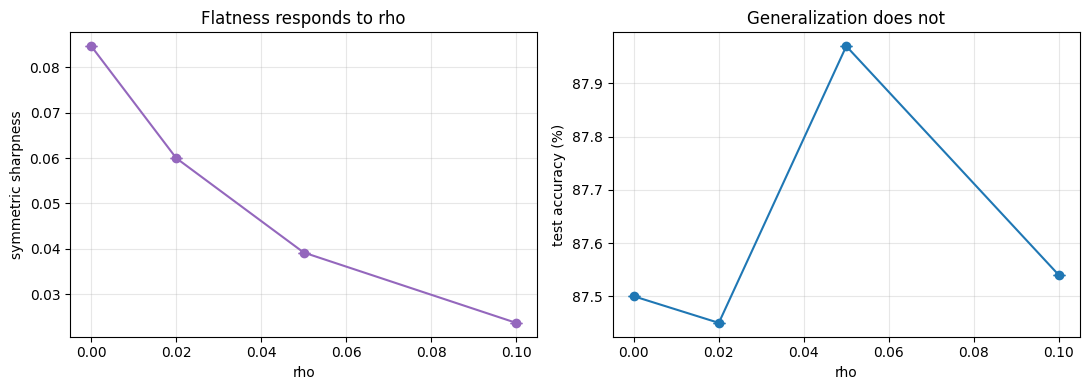

In [ ]:
# ══ 13. rho 스윕 그림 (Gate C) ════════════════════════════════════════════
by = defaultdict(lambda: {'sym': [], 'acc': []})
for a in load_arms():
    by[a['rho_max']]['sym'].append(a['results']['final_symmetric'])
    by[a['rho_max']]['acc'].append(a['results']['final_test_acc'])
rhos = sorted(by)
if len(rhos) >= 2:
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].errorbar(rhos, [mean(by[r]['sym']) for r in rhos],
                   yerr=[sd(by[r]['sym']) if len(by[r]['sym'])>1 else 0 for r in rhos],
                   marker='o', capsize=4, color='tab:purple')
    ax[0].set_xlabel('rho'); ax[0].set_ylabel('symmetric sharpness')
    ax[0].set_title('Flatness responds to rho'); ax[0].grid(alpha=.3)
    ax[1].errorbar(rhos, [mean(by[r]['acc']) for r in rhos],
                   yerr=[sd(by[r]['acc']) if len(by[r]['acc'])>1 else 0 for r in rhos],
                   marker='o', capsize=4, color='tab:blue')
    ax[1].set_xlabel('rho'); ax[1].set_ylabel('test accuracy (%)')
    ax[1].set_title('Generalization does not'); ax[1].grid(alpha=.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'fig_rho_sweep.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('rho 수준이 부족하다. 그리드를 완주할 것.')

In [ ]:
# ══ ★ 회수 (세션 끄기 전 반드시 실행) ═════════════════════════════════════
# Colab VM 은 임시다. Kaggle 에서 이미 한 번 전부 날렸다 (PROGRESS.md §8).
arc = os.path.join(OUT_DIR, 'phase1_results.tar.gz')
with tarfile.open(arc, 'w:gz') as t:
    for f in sorted(glob.glob(os.path.join(OUT_DIR, '*.json'))
                    + glob.glob(os.path.join(OUT_DIR, '*.png'))):
        t.add(f, arcname=os.path.basename(f))
print(f'{arc}  ({os.path.getsize(arc)/1024:.0f} KB)')
try:
    from google.colab import files; files.download(arc)
except Exception as e:
    print('브라우저 다운로드 불가:', e)
    print('CLI 로:  colab download -s <세션>', arc, './results/')

/content/out/phase1_results.tar.gz  (80 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>